In [424]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc,colors
import os
from salishsea_tools import visualisations as vis
import netCDF4 as nc
import pandas as pd
import matplotlib.dates as mdates

In [425]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [426]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [427]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])

In [428]:
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
vol = mask.volume.where(mask.tmask == 1).sel(t=0)

In [429]:
Zoo = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_zoo_regions.npy')
Zoo_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles2021_zoo_regions.npy')

Zoo_full = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_zoo_full.npy')
Zoo_2021_full = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles2021_zoo_full.npy')

In [430]:
def weighted_mean_concentration(mean_profile,region=None,regions=None,zmax=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        vol_r = vol

    vol_r = vol_r.sum(axis=(1,2))
    vol_r = np.array(vol_r)
    mask = (np.isfinite(mean_profile))&(mean_profile!=0)
    
    if zmax is not None:
        weighted_mean = np.nansum(mean_profile[:,:zmax] * vol_r[:zmax], axis=1) / np.nansum(mask[:,:zmax]*vol_r[:zmax],axis=1)    
    else: 
        weighted_mean = np.nansum(mean_profile * vol_r, axis=1) / np.nansum(mask*vol_r,axis=1)

    return weighted_mean

In [431]:
Z1 = Zoo[0,:,:,:]
Z2 = Zoo[1,:,:,:]

Z1_f = Zoo_full[0,:,:]
Z2_f = Zoo_full[1,:,:]

Z1_21 = Zoo_2021[0,:,:,:]
Z2_21 = Zoo_2021[1,:,:,:]

Z1_21_f = Zoo_2021_full[0,:,:]
Z2_21_f = Zoo_2021_full[1,:,:]


Z1 = np.where(Z1==0, np.nan, Z1)
Z2 = np.where(Z2==0, np.nan, Z2)

Z1_f = np.where(Z1_f==0, np.nan, Z1_f)
Z2_f = np.where(Z2_f==0, np.nan, Z2_f)

Z1_21 = np.where(Z1_21==0, np.nan, Z1_21)
Z2_21 = np.where(Z2_21==0, np.nan, Z2_21)

Z1_21_f = np.where(Z1_21_f==0, np.nan, Z1_21_f)
Z2_21_f = np.where(Z2_21_f==0, np.nan, Z2_21_f)


Z1diff = (Z1 - Z1_21)/Z1_21
Z2diff = (Z2 - Z2_21)/Z2_21

Z1diff_f = (Z1_f - Z1_21_f)/Z1_21_f
Z2diff_f = (Z2_f - Z2_21_f)/Z2_21_f

Len = Z1diff.shape[1]
z11 = np.full((len(regions.keys())+1,Len), np.nan)
z21 = np.full((len(regions.keys())+1,Len), np.nan)

for ii, region in enumerate(regions.keys()):
    z11[ii,:] = weighted_mean_concentration(Z1diff[ii,:,:], region=region, regions=regions)
    z21[ii,:] = weighted_mean_concentration(Z2diff[ii,:,:], region=region, regions=regions)   

z11_f = weighted_mean_concentration(Z1diff_f[:,:])
z21_f = weighted_mean_concentration(Z2diff_f[:,:])   

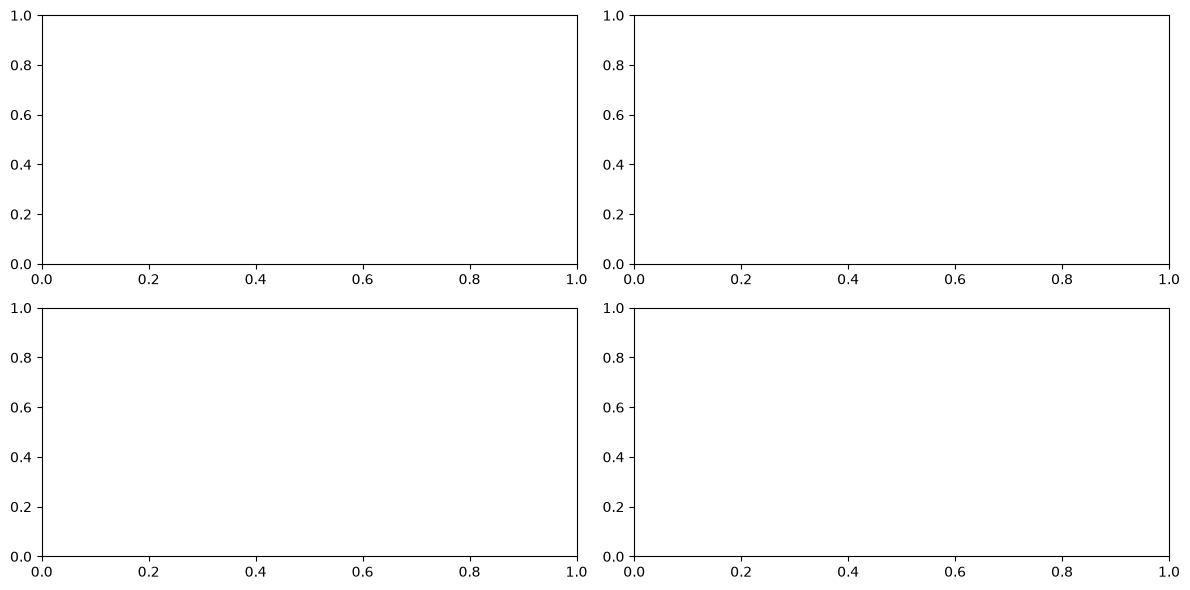

In [432]:
# Create a figure and a GridSpec layout
fig,axs = plt.subplots(2,2,figsize=(12,6))

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
axes = fig.get_axes()

In [433]:
# Weekly statistics
def weekly_statistics(values, dates):
    
    data = pd.DataFrame({'value': values}, index=dates)
    data['year'] = data.index.year
    data['week'] = ((data.index.dayofyear - 1) // 7) + 1

    annual_weekly = data.groupby(['year', 'week'])['value'].mean()
    by_week = annual_weekly.groupby('week')

    return by_week.mean(), by_week.min(), by_week.max()

In [434]:
time = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')
axes[0].clear()
axes[1].clear()
# Z1
for ii, region in enumerate(regions.keys()):
    mean, low, high = weekly_statistics(z11[ii, 365:], time[365:])
    axes[0].fill_between(mean.index,low,high,color=colors_reg[region],alpha=0.15,linewidth=0)
    axes[0].plot(mean.index,mean,color=colors_reg[region],linewidth=1.8,label=region)
# Z2
for ii, region in enumerate(regions.keys()):
    mean, low, high = weekly_statistics(z21[ii, 365:], time[365:])
    axes[1].fill_between(mean.index,low,high,color=colors_reg[region],alpha=0.15,linewidth=0)
    axes[1].plot(mean.index,mean,color=colors_reg[region],linewidth=1.8,label=region)

# Full-domain Z1
mean, low, high = weekly_statistics(z11_f[365:], time[365:])
axes[0].fill_between(mean.index, low, high,color='k',alpha=0.10,linewidth=0)
axes[0].plot(mean.index, mean,color='k',linewidth=1.8,label='Full Domain')

# Full-domain Z2
mean, low, high = weekly_statistics(z21_f[365:], time[365:])
axes[1].fill_between(mean.index, low, high,color='k',alpha=0.10,linewidth=0)
axes[1].plot(mean.index, mean,color='k',linewidth=1.8,label='Full Domain')

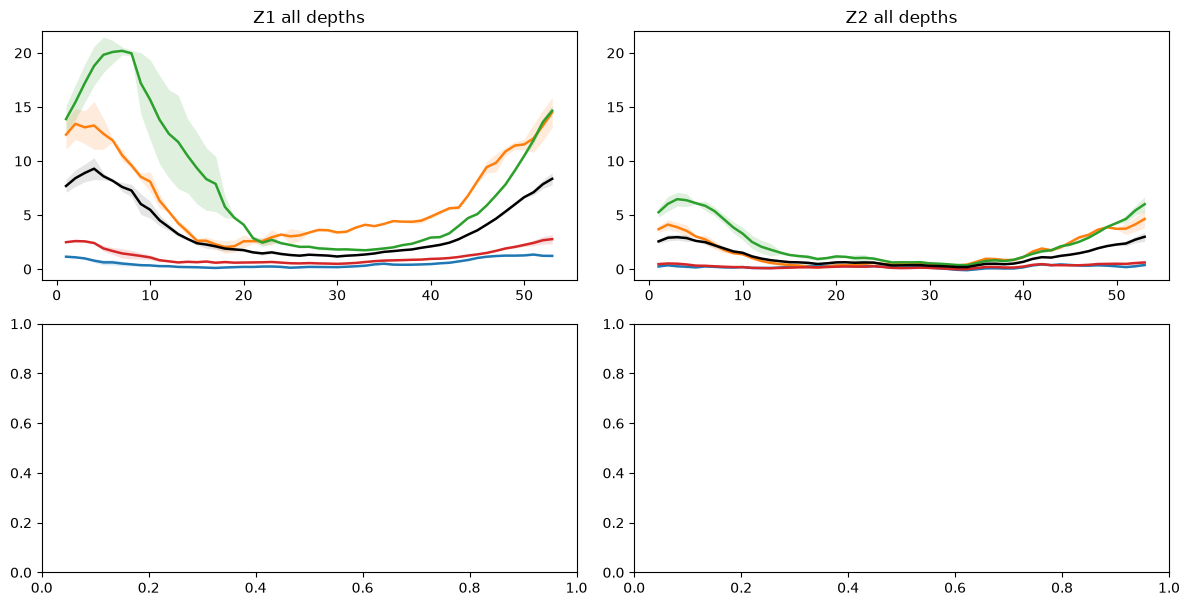

<Figure size 640x480 with 0 Axes>

In [435]:
month_starts = pd.date_range('2023-01-01', '2023-12-01', freq='MS')
month_weeks = [1, 5.33, 9.66, 14, 18.33, 22.66, 27, 31.33, 35.66, 40, 44.33, 48.66]

month_labels = month_starts.strftime('%b')

axes[0].set_title('Z1 all depths')
axes[1].set_title('Z2 all depths')
#axes[1].set_title('Changes in Z2 (mmol N/m3) vs v202111')

axes[0].set_ylim([-1,22])
axes[1].set_ylim([-1,22])


plt.tight_layout()
fig

In [436]:
Len = Z1diff.shape[1]
z11 = np.full((len(regions.keys())+1,Len), np.nan)
z21 = np.full((len(regions.keys())+1,Len), np.nan)

for ii, region in enumerate(regions.keys()):
    z11[ii,:] = weighted_mean_concentration(Z1diff[ii,:,:], region=region, regions=regions,zmax = 10)
    z21[ii,:] = weighted_mean_concentration(Z2diff[ii,:,:], region=region, regions=regions,zmax = 10)
    
z11_f = weighted_mean_concentration(Z1diff_f[:,:],zmax = 10)
z21_f = weighted_mean_concentration(Z2diff_f[:,:],zmax = 10) 

In [437]:
time = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')
axes[2].clear()
axes[3].clear()
# Z1
for ii, region in enumerate(regions.keys()):
    mean, low, high = weekly_statistics(z11[ii, 365:], time[365:])
    axes[2].fill_between(mean.index,low,high,color=colors_reg[region],alpha=0.15,linewidth=0)
    axes[2].plot(mean.index,mean,color=colors_reg[region],linewidth=1.8,label=region)
# Z2
for ii, region in enumerate(regions.keys()):
    mean, low, high = weekly_statistics(z21[ii, 365:], time[365:])
    axes[3].fill_between(mean.index,low,high,color=colors_reg[region],alpha=0.15,linewidth=0)
    axes[3].plot(mean.index,mean,color=colors_reg[region],linewidth=1.8,label=region)

# Full-domain Z1
mean, low, high = weekly_statistics(z11_f[365:], time[365:])
axes[2].fill_between(mean.index, low, high,color='k',alpha=0.10,linewidth=0)
axes[2].plot(mean.index, mean,color='k',linewidth=1.8,label='Full Domain')

# Full-domain Z2
mean, low, high = weekly_statistics(z21_f[365:], time[365:])
axes[3].fill_between(mean.index, low, high,color='k',alpha=0.10,linewidth=0)
axes[3].plot(mean.index, mean,color='k',linewidth=1.8,label='Full Domain')

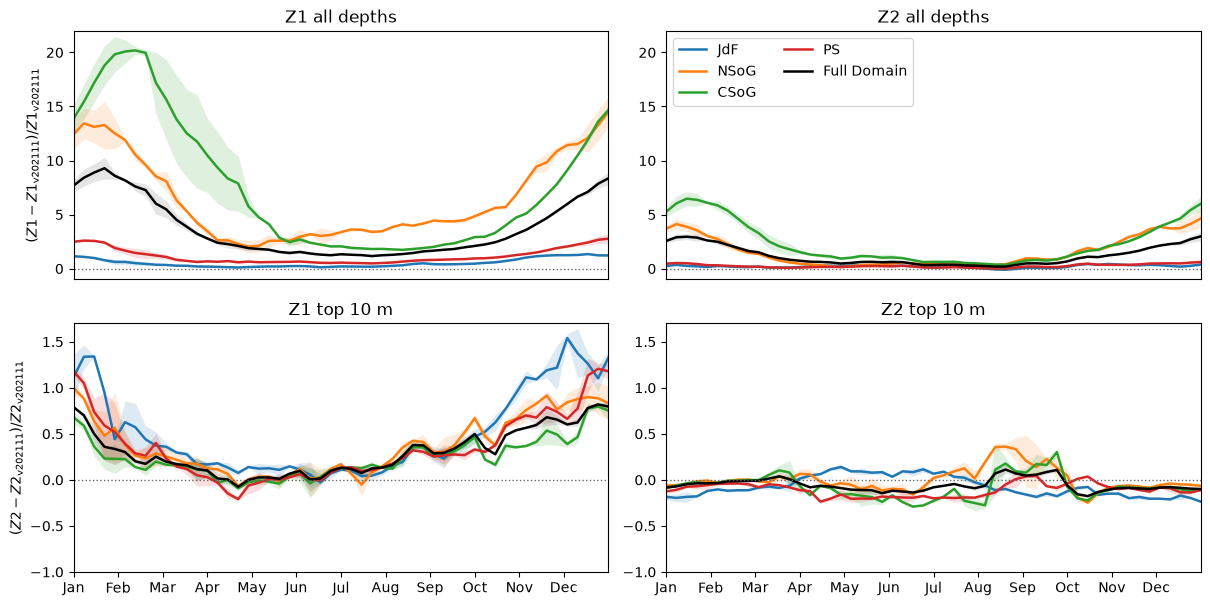

<Figure size 640x480 with 0 Axes>

In [438]:
month_starts = pd.date_range('2023-01-01', '2023-12-01', freq='MS')
month_weeks = [1, 5.33, 9.66, 14, 18.33, 22.66, 27, 31.33, 35.66, 40, 44.33, 48.66]

month_labels = month_starts.strftime('%b')

axes[2].set_title('Z1 top 10 m')
axes[3].set_title('Z2 top 10 m')

for ax in axes:
    ax.axhline(0, color='0.4', linestyle=':', linewidth=1)
    ax.set_xlim(1, 53)
    ax.set_xticks(month_weeks)

axes[3].set_xticklabels(month_labels)
axes[2].set_xticklabels(month_labels)
axes[0].set_xticks([])
axes[1].set_xticks([])

axes[2].set_ylim([-1,1.7])
axes[3].set_ylim([-1,1.7])

axes[0].set_ylabel( r'$(Z1 - Z1_{\mathrm{v202111}})/Z1_{\mathrm{v202111}}$')
axes[2].set_ylabel( r'$(Z2 - Z2_{\mathrm{v202111}})/Z2_{\mathrm{v202111}}$')

handles, labels = axes[1].get_legend_handles_labels()

axes[1].legend(
    handles,
    labels,
    loc='upper left',
    frameon=True,
    ncol=2
)

plt.tight_layout()
fig

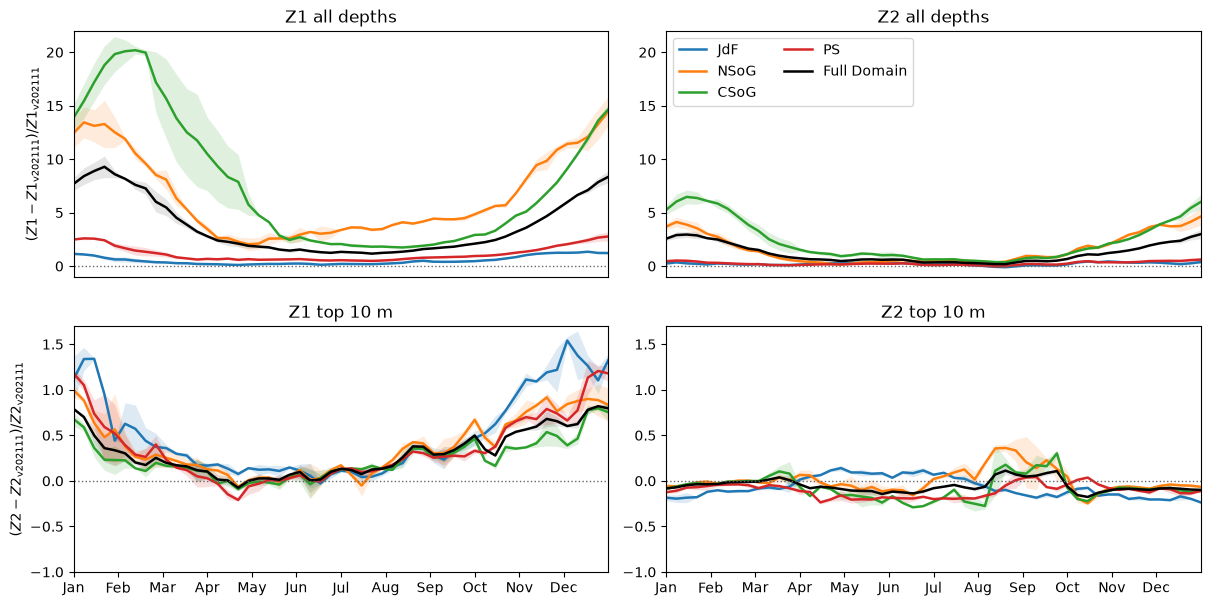

In [439]:
fig.subplots_adjust(hspace=0.2)
fig

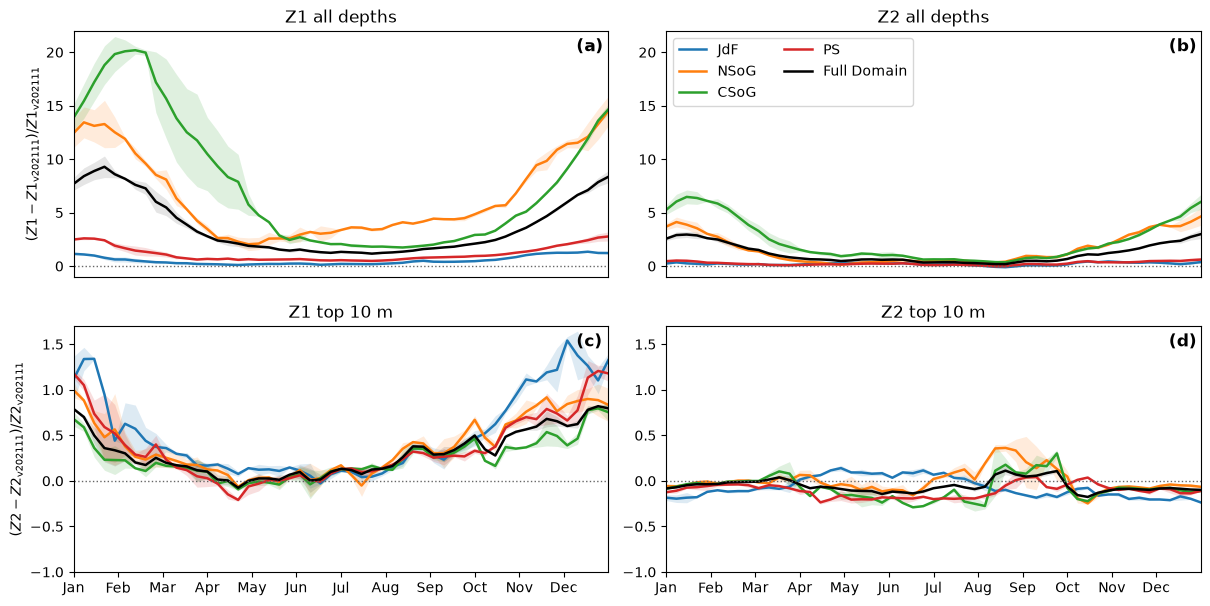

In [440]:
letters = ['(a)', '(b)', '(c)', '(d)']

axes[0].text(0.94, 0.97, letters[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1].text(0.94, 0.97, letters[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0.94, 0.97, letters[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')
axes[3].text(0.94, 0.97, letters[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold', va='top')
fig

In [441]:
fig.savefig('zooplankton.pdf',bbox_inches='tight')